In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'

In [3]:
RESULTS_DIR = "results"
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

ABLATIONS = [
    ("clf",        r"$\lambda_{\text{clf}}$",         "cellina-clf"),
    ("disc",       r"$\lambda_{\text{disc}}$",        "cellina-disc"),
    ("domain_clf", r"$\lambda_{\text{domain\_clf}}$", "cellina-domain_clf"),
    ("graph",      r"$\lambda_{\text{graph}}$",        "cellina-graph-contrastive"),
]

dfs = {}
for key, _, _ in ABLATIONS:
    path = os.path.join(RESULTS_DIR, f"ablation_{key}.csv")
    if os.path.exists(path):
        dfs[key] = pd.read_csv(path)
        print(f"{key}: {len(dfs[key])} rows")
    else:
        print(f"{key}: NOT FOUND ({path})")

clf: 144 rows
disc: 144 rows
domain_clf: 144 rows
graph: 69 rows


## Figure 1 — F1 scores (4 panels)

/tmp/ipykernel_3057961/1346829298.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3057961/1346829298.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3057961/1346829298.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3057961/1346829298.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib

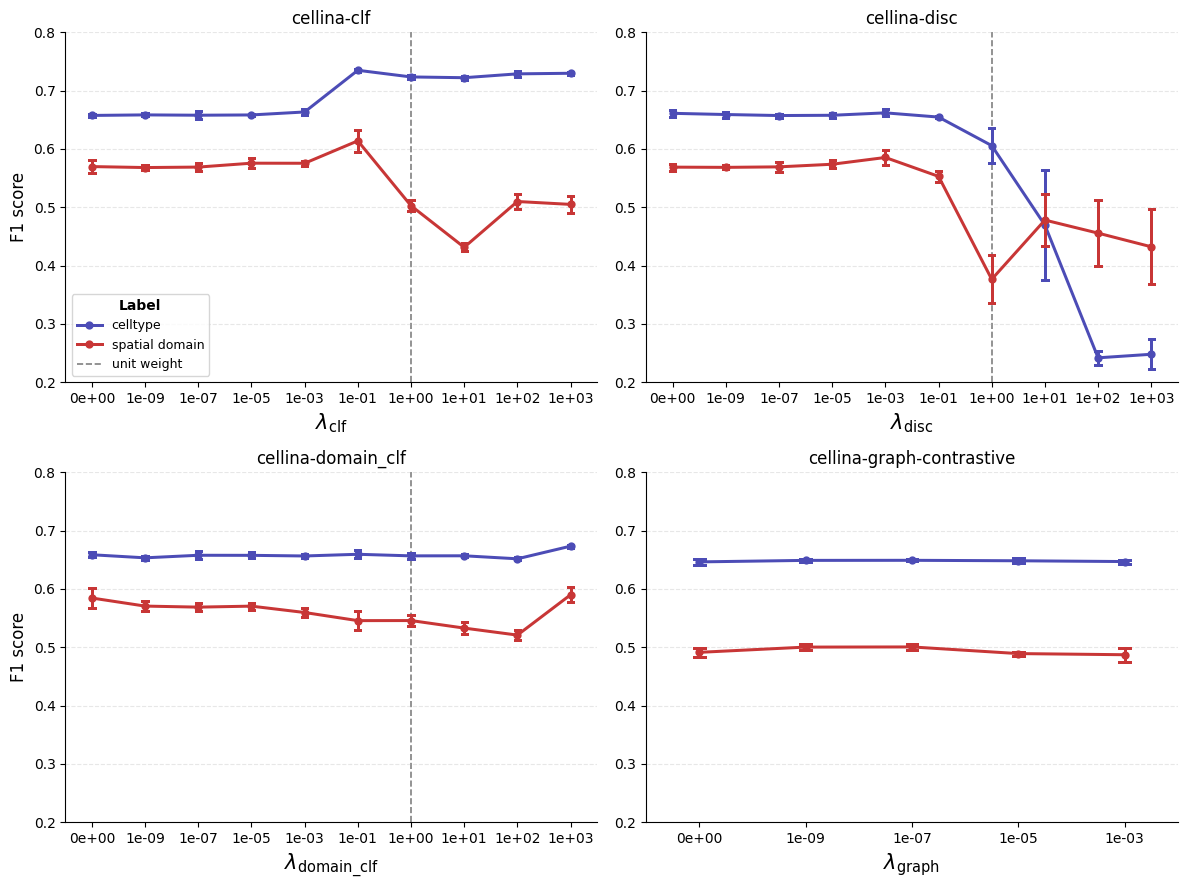

In [4]:
F1_PALETTE = {
    "F1_celltype":       "#4C4CB6",
    "F1_spatial_domain": "#C83636",
}
F1_LABEL_MAP = {
    "F1_celltype":       "celltype",
    "F1_spatial_domain": "spatial domain",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
flat_axes = axes.flatten()
for ax_i, (key, xlabel, title) in enumerate(ABLATIONS):
    ax = flat_axes[ax_i]
    if key not in dfs:
        ax.set_title(title + "\n(no data)", fontsize=13)
        continue

    df = dfs[key][dfs[key]["metric"].isin(["F1_celltype", "F1_spatial_domain"])].copy()
    lambda_order = sorted(df["lambda"].unique())
    lambda_strs = [f"{lv:.0e}" for lv in lambda_order]
    df["lambda_str"] = df["lambda"].map(lambda x: f"{x:.0e}")
    df["label"] = df["metric"].map(F1_LABEL_MAP)

    palette_mapped = {F1_LABEL_MAP[k]: v for k, v in F1_PALETTE.items()}

    # pointplot defaults to dodge=False, which aligns everything to the tick center.
    sns.pointplot(
        data=df,
        x="lambda_str",
        y="score",
        hue="label",
        palette=palette_mapped,
        order=lambda_strs,
        dodge=False,         # Points are now perfectly centered on the x-axis tick
        markers="o",
        linestyles="-",
        errorbar="sd",       # Mean + Standard Deviation for variance
        capsize=0.1,
        scale=0.8,
        ax=ax,
    )

    if "1e+00" in lambda_strs:
        idx = lambda_strs.index("1e+00")
        ax.axvline(x=idx, color="gray", linestyle="--", linewidth=1.2,
                   label="unit weight", zorder=0)

    # Clean up the visuals
    ax.set_ylim(0.2, 0.8)
    ax.yaxis.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_title(title, fontsize=12)

    if ax_i % 2 == 0:
        ax.set_ylabel("F1 score", fontsize=12)
    else:
        ax.set_ylabel("")

    # Legend only on the first subplot
    handles, labels_leg = ax.get_legend_handles_labels()
    if ax_i == 0:
        leg = ax.legend(handles=handles, labels=labels_leg, title="Label",
                        title_fontsize=10, fontsize=9, loc="lower left", framealpha=0.8)
        leg.get_title().set_fontweight("bold")
    else:
        if ax.get_legend():
            ax.get_legend().remove()

plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "ablations_f1.svg"), bbox_inches="tight")
plt.show()

## Figure 2 — Marginal log-likelihood (4 panels)

/tmp/ipykernel_3057961/1344745561.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3057961/1344745561.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3057961/1344745561.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3057961/1344745561.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib

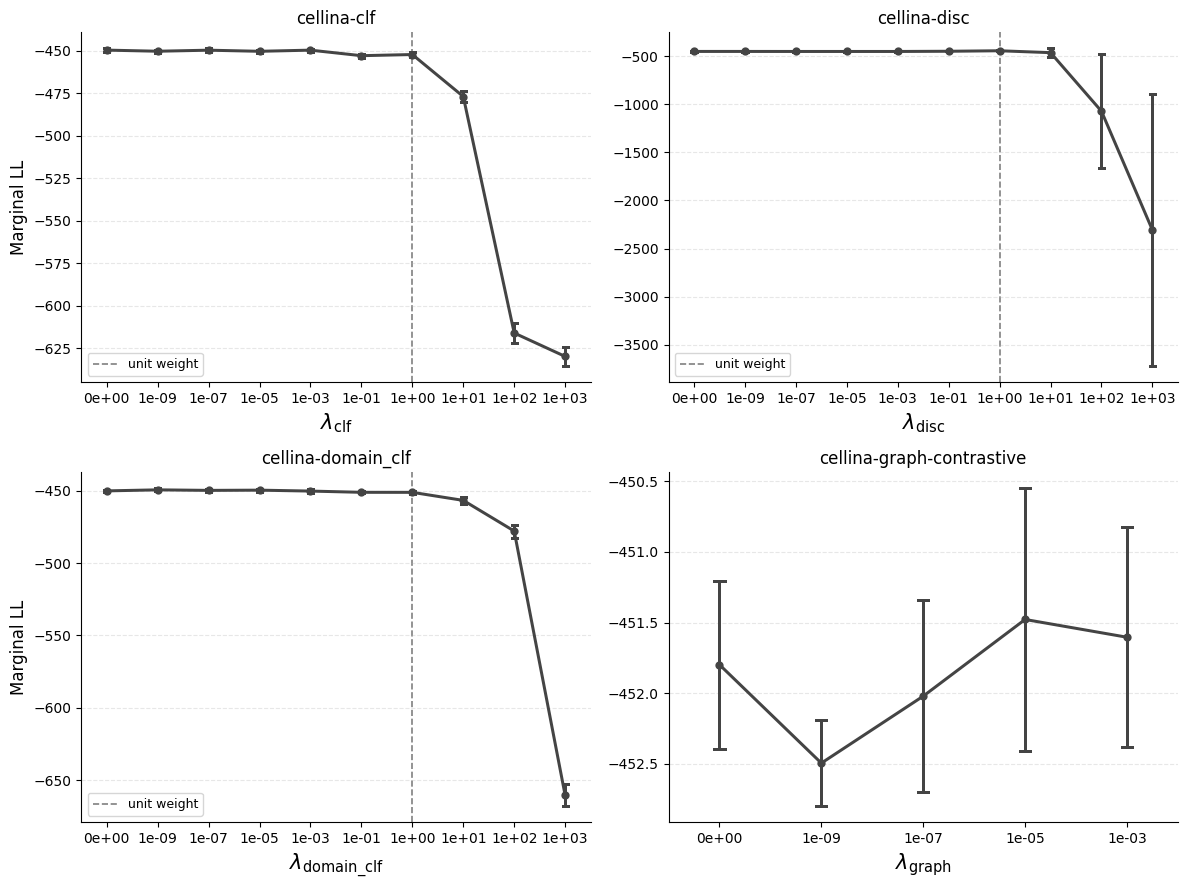

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
flat_axes = axes.flatten()

for ax_i, (key, xlabel, title) in enumerate(ABLATIONS):
    ax = flat_axes[ax_i]
    if key not in dfs:
        ax.set_title(title + "\n(no data)", fontsize=13)
        continue

    # Filter for the metric and create string labels for x-axis consistency
    df = dfs[key][dfs[key]["metric"] == "marginal_ll"].copy()
    lambda_order = sorted(df["lambda"].unique())
    lambda_strs = [f"{lv:.0e}" for lv in lambda_order]
    df["lambda_str"] = df["lambda"].map(lambda x: f"{x:.0e}")

    # Plot the average line and variance (SD)
    # Aligning everything to the x-axis ticks (no jitter, no dodge)
    sns.pointplot(
        data=df,
        x="lambda_str",
        y="score",
        order=lambda_strs,
        color="#444444",     # Matching your original scatter color
        markers="o",
        linestyles="-",
        errorbar="sd",       # Mean + Standard Deviation
        capsize=0.1,
        scale=0.8,
        ax=ax
    )

    # Vertical line for unit weight
    if "1e+00" in lambda_strs:
        idx = lambda_strs.index("1e+00")
        ax.axvline(x=idx, color="gray", linestyle="--", linewidth=1.2,
                   label="unit weight", zorder=0)
        # Only add legend if the unit weight line is present
        ax.legend(fontsize=9, loc="lower left", framealpha=0.8)

    # Aesthetics
    ax.yaxis.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_title(title, fontsize=12)

    if ax_i % 2 == 0:
        ax.set_ylabel("Marginal LL", fontsize=12)
    else:
        ax.set_ylabel("")

plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "ablations_mll.svg"), bbox_inches="tight")
plt.show()